# `QUModel` Tutorial

Trey V. Wenger (c) March 2025

Here we demonstrate the basic features of the `QUModel` model. The `QUModel` predicts Stokes Q and U spectra by decomposing the line-of-sight into a series of Faraday-thin (delta function) or Faraday-thick (Gaussian) components. Please review the `bayes_spec` documentation and tutorials for a more thorough description of the steps outlined in this tutorial: https://bayes-spec.readthedocs.io/en/stable/index.html

In [1]:
# General imports    
import os
import pickle
import time

import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm

print("pymc version:", pm.__version__)

import bayes_spec
print("bayes_spec version:", bayes_spec.__version__)

import bayes_pol
print("bayes_pol version:", bayes_pol.__version__)

# Notebook configuration
pd.options.display.max_rows = None

pymc version: 5.21.1
bayes_spec version: 1.7.5
bayes_pol version: 1.0+14.g39245d2.dirty


## Simulating Data

To test the model, we must simulate some data. We can do this with `QUModel`, but we must pack a "dummy" data structure first. Here we construct a dataset that is similar to a "real" dataset: multiple non-contiguous frequency windows, uniform sampling in frequency, and different noise properties in each window.

In [2]:
from bayes_spec import SpecData

# speed of light (m Hz)
_C = 2.99792458e+08

# frequency windows (start_edge (Hz), stop_edge (Hz), n_channels, spectral rms (%))
freq_windows = [
#    (0.5e9, 0.8e9, 128, 0.5),
    (1.1e9, 1.4e9, 128, 0.01),
#    (2.0e9, 2.1e9, 64, 0.1),
]

# storage for dummy data, concatenated Stokes data, and wavelength bin data
dummy_data = {}
all_lam2_axis = []
all_stokesQ = []
all_stokesU = []
lam2_lower = []
lam2_upper = []
lam2_chans = []
lam2_channel_widths = []

# loop over windows
for i, window in enumerate(freq_windows):
    # construct frequency bins
    freq_bin_edges = np.linspace(window[0], window[1], window[2]+1)
    freq_bin_width = np.diff(freq_bin_edges)[0]

    # frequency bin centers
    freq_axis = freq_bin_edges[:-1] + freq_bin_width/2.0

    # convert to wavelength bins
    lam2_bin_edges = (_C/freq_bin_edges[::-1])**2.0
    lam2_bin_widths = np.diff(lam2_bin_edges)

    # (weighted) wavelength^2 bin centers
    lam2_axis = lam2_bin_edges[:-1] + _C**2.0/freq_axis[::-1]**3.0 * freq_bin_width
    
    # random Stokes data for now
    stokesQ = window[3] * np.random.randn(len(lam2_axis))
    stokesU = window[3] * np.random.randn(len(lam2_axis))

    dummy_data[f"Q{i}"] = SpecData(
        lam2_axis, # spectral
        stokesQ, # brightness
        window[3], # rms
        xlabel = r"$\lambda^2$ (m$^2$)",
        ylabel = r"$Q/I$",
    )
    dummy_data[f"U{i}"] = SpecData(
        lam2_axis, # spectral
        stokesU, # brightness
        window[3], # rms
        xlabel = r"$\lambda^2$ (m$^2$)",
        ylabel = r"$U/I$",
    )
    
    # save data
    all_lam2_axis.append(lam2_axis)
    all_stokesQ.append(stokesQ)
    all_stokesU.append(stokesU)
    lam2_lower.append(lam2_bin_edges.min())
    lam2_upper.append(lam2_bin_edges.max())
    lam2_chans.append(len(lam2_axis))
    lam2_channel_widths.append(lam2_bin_widths)

# concatenate along window axis
lam2_axis = np.concatenate(all_lam2_axis)
stokesQ = np.concatenate(all_stokesQ)
stokesU = np.concatenate(all_stokesU)

Now we construct the Faraday spectrum from the (random, for now) Stokes Q and U data.

Faraday depth max scale: 20359.4 rad/m2
Faraday depth resolution: 111.5 rad/m2
Faraday bins: 225
Faraday bin width: 4.5 rad/m2
Independent Faraday bins: 8
Wavelength bins: 128


/tmp/ipykernel_386749/3357641024.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


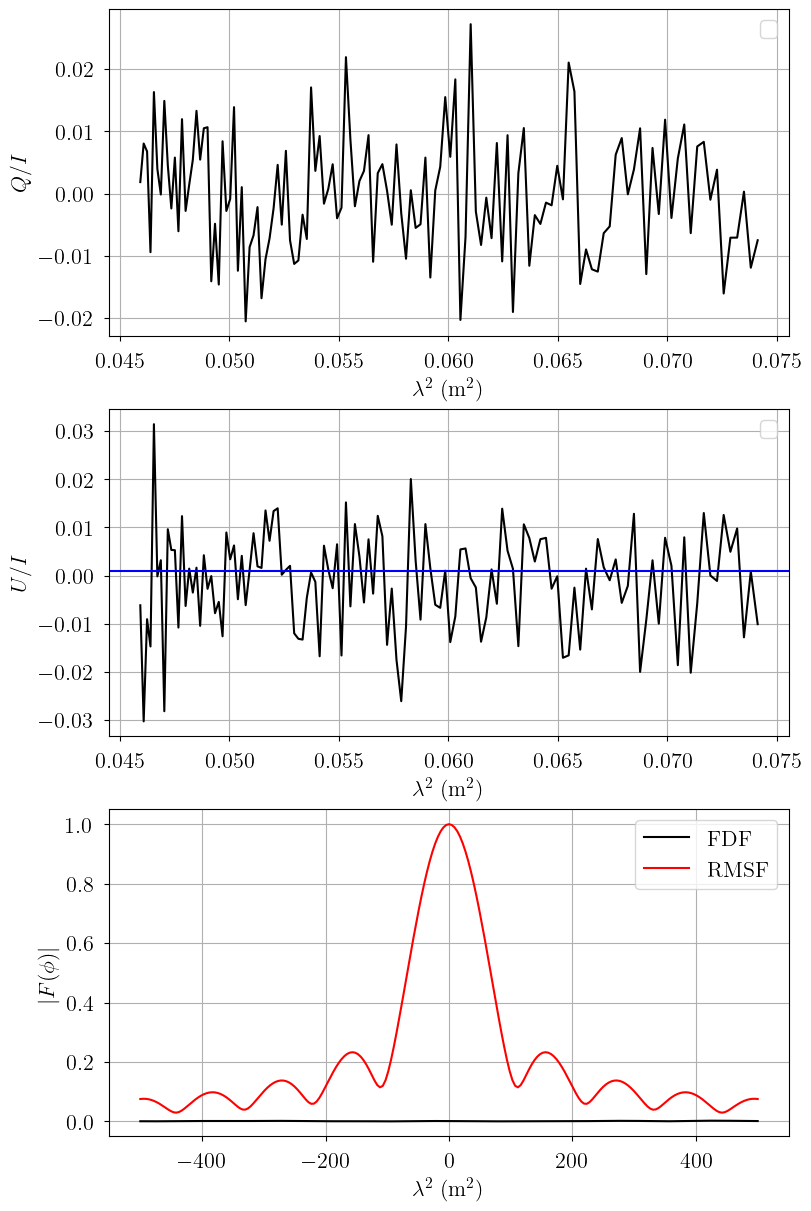

In [3]:
from bayes_pol.utils import construct_faraday_spectrum, construct_rmsf
from bayes_spec import SpecData

# Tunable parameters
faraday_width = 1000.0 # rad/m2
resolution_factor = 25 # Faraday bins per resolution element

# Faraday depth spectral axis
max_scale = np.pi/np.abs(np.diff(lam2_axis)).min()
resolution = np.pi/np.ptp(lam2_axis)

N_bins = int(resolution_factor * faraday_width / resolution)
if N_bins % 2 == 0:
    N_bins += 1
faraday_depth_axis = np.linspace(-faraday_width/2.0, faraday_width/2.0, N_bins)
print(f"Faraday depth max scale: {max_scale:0.1f} rad/m2")
print(f"Faraday depth resolution: {resolution:0.1f} rad/m2")
print(f"Faraday bins: {N_bins:d}")
print(f"Faraday bin width: {np.diff(faraday_depth_axis)[0]:0.1f} rad/m2")
print(f"Independent Faraday bins: {int(faraday_width/resolution):d}")
print(f"Wavelength bins: {len(lam2_axis):d}")

# construct FDF from Stokes Q and U
faraday_depth_real, faraday_depth_imag = construct_faraday_spectrum(faraday_depth_axis, lam2_axis, stokesQ, stokesU)
faraday_depth_abs = np.sqrt(faraday_depth_real.eval()**2.0 + faraday_depth_imag.eval()**2.0)
faraday_depth_rms = np.sqrt(np.sum([window[2]*window[3]**2.0 for window in freq_windows])/len(lam2_axis)**2.0)

# construct RMSF
rmsf_real, rmsf_imag = construct_faraday_spectrum(faraday_depth_axis, lam2_axis, np.ones_like(stokesQ), np.zeros_like(stokesU))
rmsf_abs = np.sqrt(rmsf_real.eval()**2.0 + rmsf_imag.eval()**2.0)

# Plot the simulated data
fig, axes = plt.subplots(len(dummy_data)+1, figsize=(8, 4*(len(dummy_data)+1)), layout="constrained", squeeze=False)
for ax, dataset in zip(axes.ravel(), dummy_data.values()):
    ax.plot(dataset.spectral, dataset.brightness, "k-")
    ax.set_xlabel(dataset.xlabel)
    ax.set_ylabel(dataset.ylabel)
    ax.legend(loc='best')
ax.axhline(faraday_depth_rms, color='b', label='rms')

ax = axes.ravel()[-1]
ax.plot(faraday_depth_axis, faraday_depth_abs, 'k-', label='FDF')
ax.plot(faraday_depth_axis, rmsf_abs, 'r-', label="RMSF")
ax.set_xlabel(dataset.xlabel)
ax.set_ylabel(r"$|F(\phi)|$")
ax.legend(loc='best')

Now that we have a dummy data format, we can generate a simulated observation by evaluating the model for a given set of parameters. We mimic a "real" dataset by constructing the Faraday spectrum from Stokes Q and U (rather than simulating it from the model). We compare it to the model prediction as a test of the model.

In [ ]:
from bayes_pol import QUModel

# Initialize and define the model
n_clouds = 2 # number of cloud components
model = QUModel(
    dummy_data,
    n_clouds=n_clouds,
    seed=1234,
    verbose=True
)
model.add_priors(
    prior_faraday_depth_mean = [faraday_depth_axis, faraday_depth_abs**2.0],
    prior_faraday_depth_fwhm = 25.0,
)
model.add_likelihood()

# simulation parameters
sim_params = {
    "polarization_fraction": np.array([0.8, 0.4]),
    "faraday_depth_mean": np.array([-50.0, 250.0]),
    "faraday_depth_fwhm": np.array([0.0, 30.0]),
    "pol_angle0": np.array([-0.25, 0.45]),
}

# simulate observations
sim_obs = {
    key: model.model[key].eval(sim_params, on_unused_input="ignore")
    for key in dummy_data.keys()
}

# construct Faraday spectrum from Stokes Q and U.
stokesQ = np.concatenate([sim_obs[key] for key in sim_obs.keys() if "Q" in key])
stokesU = np.concatenate([sim_obs[key] for key in sim_obs.keys() if "U" in key])
faraday_depth_real, faraday_depth_imag = construct_faraday_spectrum(faraday_depth_axis, lam2_axis, stokesQ, stokesU)
faraday_depth_abs = np.sqrt(faraday_depth_real.eval()**2.0 + faraday_depth_imag.eval()**2.0)

# save data
data = {}
for key in dummy_data.keys():
    data[key] = SpecData(
        dummy_data[key].spectral,
        sim_obs[key],
        dummy_data[key].noise,
        xlabel=dummy_data[key].xlabel,
        ylabel=dummy_data[key].ylabel,
    )

# Plot the simulated data
fig, axes = plt.subplots(len(data), figsize=(8, 12), layout="constrained", squeeze=False)
for ax, dataset in zip(axes.ravel(), data.values()):
    ax.plot(dataset.spectral, dataset.brightness, "k.")
    ax.set_xlabel(dataset.xlabel)
    ax.set_ylabel(dataset.ylabel)
#ax.plot(dataset.spectral, sim_obs["faraday_depth_abs"], "r-", label="Model")
#ax.legend(loc="upper right")
#ax.set_xlim(-5000, 5000)

## Model Definition

Finally, with our model definition and (simulated) data in hand, we can explore the capabilities of `FaradayModel`. Here we create a new model with the simulated data.

In [ ]:
# Initialize and define the model
model = QUModel(
    data,
    n_clouds=n_clouds,
    seed=1234,
    verbose=True
)
model.add_priors(
    prior_faraday_depth_mean = [faraday_depth_axis, faraday_depth_abs**2.0],
    prior_faraday_depth_fwhm = 25.0,
)
model.add_likelihood()

In [ ]:
# Plot model graph
model.graph().render('qu_model', format='png')
model.graph()

In [ ]:
# model string representation
print(model.model.str_repr())

We check that our prior distributions are reasonable by drawing prior predictive checks. Each colored line is a simulated "observation" with parameters drawn from the prior distributions. You should check that these simulated observations at least somewhat overlap your actual observation (black line).

In [ ]:
from bayes_spec.plots import plot_predictive

# prior predictive check
prior = model.sample_prior_predictive(
    samples=100,  # prior predictive samples
)
axes = plot_predictive(model.data, prior.prior_predictive)
axes.ravel()[0].figure.set_size_inches(8, 16)

Finally, we check the prior distributions of the derived (deterministic) quantities. The red points show the "true" values for our simulated observation.

In [ ]:
from bayes_spec.plots import plot_pair

_ = plot_pair(
    prior.prior, # samples
    model.cloud_deterministics + ["polarization_fraction", "faraday_depth_mean"],
    labeller=model.labeller, # label manager
    kind="kde", # plot type
    reference_values=sim_params, # truths
)

## Variational Inference

We can approximate the posterior distribution using variational inference.

In [ ]:
start = time.time()
model.fit(
    n = 100_000, # maximum number of VI iterations
    draws = 1_000, # number of posterior samples
    rel_tolerance = 0.001, # VI relative convergence threshold
    abs_tolerance = 0.001, # VI absolute convergence threshold
    learning_rate = 0.01, # VI learning rate
)
end = time.time()
print(f"Runtime: {(end-start)/60.0:.2f} minutes")

In [ ]:
# ignore transition and state dependent parameters
pm.summary(model.trace.posterior)

In [ ]:
posterior = model.sample_posterior_predictive(
    thin=100, # keep one in {thin} posterior samples
)
axes = plot_predictive(model.data, posterior.posterior_predictive)
axes.ravel()[0].figure.set_size_inches(8, 16)

## Posterior Sampling: MCMC

We can sample from the posterior distribution using MCMC.

In [ ]:
model.sample_smc(chains=4, cores=4)

In [ ]:
start = time.time()
model.sample(
    #init = "advi+adapt_diag", # initialization strategy
    init="auto",
    tune = 1000, # tuning samples
    draws = 1000, # posterior samples
    chains = 8, # number of independent chains
    cores = 8, # number of parallel chains
    init_kwargs = {"rel_tolerance": 0.05, "abs_tolerance": 0.05, "learning_rate": 0.01}, # VI initialization arguments
    nuts_kwargs = {"target_accept": 0.8}, # NUTS arguments
)
end = time.time()
print(f"Runtime: {(end-start)/60.0:.2f} minutes")

In [ ]:
model.solve(kl_div_threshold=0.1)

In [ ]:
print("solutions:", model.solutions)
pm.summary(model.trace.solution_0)

We generate posterior predictive checks as well as a trace plot of the individual chains. In the posterior predictive plot, we show each chain as a different color. Each line is one posterior sample.

In [ ]:
posterior = model.sample_posterior_predictive(
    thin=100, # keep one in {thin} posterior samples
)
_ = plot_predictive(model.data, posterior.posterior_predictive)

In [ ]:
from bayes_spec.plots import plot_traces

_ = plot_traces(model.trace.posterior, model.cloud_freeRVs)

We can inspect the posterior distribution pair plots. First, the normalized, free cloud parameters.

In [ ]:
from bayes_spec.plots import plot_pair

_ = plot_pair(
    model.trace.posterior, # samples
    model.cloud_freeRVs, # var_names to plot
    labeller=model.labeller, # label manager
)

Notice that there are three posterior modes. These correspond to the three clouds of the model. We can plot the posterior distributions of the deterministic quantities for a single cloud.

In [ ]:
_ = plot_pair(
    model.trace.solution_0.sel(cloud=0), # samples
    model.cloud_deterministics, # var_names to plot
    labeller=model.labeller, # label manager
)

In [ ]:
_ = plot_pair(
    model.trace.solution_0.sel(cloud=1), # samples
    model.cloud_deterministics, # var_names to plot
    labeller=model.labeller, # label manager
)

In [ ]:
_ = plot_pair(
    model.trace.solution_0.sel(cloud=2), # samples
    model.cloud_deterministics, # var_names to plot
    labeller=model.labeller, # label manager
)

Finally, we can get the posterior statistics, Bayesian Information Criterion (BIC), etc.

In [ ]:
point_stats = az.summary(model.trace.solution_0, var_names=model.cloud_deterministics, kind='stats', hdi_prob=0.68)
print("BIC:", model.bic())
display(point_stats)